# Tartu Area-Time Risk Prediction
This file contains two models which try to prdict the incident_ammount variable from the data.
1. linear regression
2. decision tree
the goal is to try predict the incident_ammount variable from the data.

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score

We're using synthetic data that we made ourselves for the dataframe.

In [232]:
df = pd.read_csv('tartu_risk_dataset_2.csv')
df

,id,area,time,population,area_km2,area_population_density,foot_traffic,area_type,socially_vulnerable_zone,minorities_zone,student_zone,nightlife_zone,day_of_week,hour,is_weekend,is_night,weather,incident_count
0,1,Annelinn,2026-01-28 0:00:00,24981,4.910,5088,medium,residential,1,1,0,1,Wednesday,0,0,1,clear,1
1,2,Ihaste,2026-01-28 0:00:00,3050,4.800,635,low,residential,0,0,0,0,Wednesday,0,0,1,clear,0
2,3,Jaamamõisa,2026-01-28 0:00:00,3464,1.500,2309,low,residential,1,1,0,0,Wednesday,0,0,1,clear,0
3,4,Karlova,2026-01-28 0:00:00,8748,2.683,3261,medium,residential,1,0,1,1,Wednesday,0,0,1,clear,0
4,5,Kesklinn,2026-01-28 0:00:00,6956,1.799,3867,high,commercial,1,1,1,1,Wednesday,0,0,1,clear,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38875,38876,Tähtvere,2026-04-27 23:00:00,3158,2.500,1263,low,residential,0,0,0,0,Monday,23,0,1,rain,0
38876,38877,Vaksali,2026-04-27 23:00:00,3091,0.666,4641,medium,mixed,0,0,1,1,Monday,23,0,1,rain,1
38877,38878,Variku,2026-04-27 23:00:00,1714,0.761,2252,low,residential,1,0,0,0,Monday,23,0,1,rain,0
38878,38879,Veeriku,2026-04-27 23:00:00,5070,2.823,1796,medium,residential,0,1,0,0,Monday,23,0,1,rain,0


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

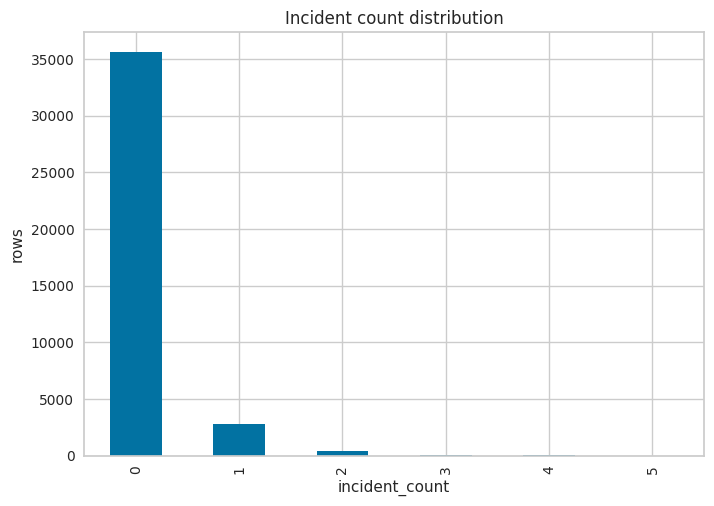

In [233]:
ax = df["incident_count"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Incident count distribution")
ax.set_xlabel("incident_count")
ax.set_ylabel("rows")
plt.show()

We're dropping the id and time variables as they are not needed.

In [234]:
target = "incident_count"
#a = ['area','day_of_week','hour','is_weekend','is_night','weather']
X = df.drop(columns=[target,'id','time']).values
#X = df[a].values
#y = df[target].values
X = pd.DataFrame(X, columns=['area','population','area_km2','area_population_density','foot_traffic','area_type','socially_vulnerable_zone','minorities_zone','student_zone','nightlife_zone','day_of_week','hour','is_weekend','is_night','weather'])
#X = pd.DataFrame(X, columns=['area','day_of_week','hour','is_weekend','is_night','weather'])
y = pd.DataFrame(y, columns=['incident_count'])
print(X.shape)
print(y.shape)
X

(38880, 15)
(38880, 1)


,area,population,area_km2,area_population_density,foot_traffic,area_type,socially_vulnerable_zone,minorities_zone,student_zone,nightlife_zone,day_of_week,hour,is_weekend,is_night,weather
0,Annelinn,24981,4.91,5088,medium,residential,1,1,0,1,Wednesday,0,0,1,clear
1,Ihaste,3050,4.8,635,low,residential,0,0,0,0,Wednesday,0,0,1,clear
2,Jaamamõisa,3464,1.5,2309,low,residential,1,1,0,0,Wednesday,0,0,1,clear
3,Karlova,8748,2.683,3261,medium,residential,1,0,1,1,Wednesday,0,0,1,clear
4,Kesklinn,6956,1.799,3867,high,commercial,1,1,1,1,Wednesday,0,0,1,clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38875,Tähtvere,3158,2.5,1263,low,residential,0,0,0,0,Monday,23,0,1,rain
38876,Vaksali,3091,0.666,4641,medium,mixed,0,0,1,1,Monday,23,0,1,rain
38877,Variku,1714,0.761,2252,low,residential,1,0,0,0,Monday,23,0,1,rain
38878,Veeriku,5070,2.823,1796,medium,residential,0,1,0,0,Monday,23,0,1,rain


Next we will encode the data with OneHotEncoder.

In [235]:
#categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
categorical_columns = ['area','foot_traffic','area_type','day_of_week','weather']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_X = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
X_encoded = pd.concat([X, one_hot_X], axis=1)
X_encoded = X_encoded.drop(categorical_columns, axis=1)

X_encoded

,population,area_km2,area_population_density,socially_vulnerable_zone,minorities_zone,student_zone,nightlife_zone,hour,is_weekend,is_night,...,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,weather_clear,weather_other_extremes,weather_rain,weather_snow,weather_storm
0,24981,4.91,5088,1,1,0,1,0,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,3050,4.8,635,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,3464,1.5,2309,1,1,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,8748,2.683,3261,1,0,1,1,0,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,6956,1.799,3867,1,1,1,1,0,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38875,3158,2.5,1263,0,0,0,0,23,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
38876,3091,0.666,4641,0,0,1,1,23,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
38877,1714,0.761,2252,1,0,0,0,23,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
38878,5070,2.823,1796,0,1,0,0,23,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Spliting the data into training and test data.

In [236]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state = 42)
#X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.8, random_state = 42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(31104, 46)
(31104, 1)
(7776, 46)
(7776, 1)


Creating the linear regression model and using it to predict the test data.

In [237]:
lin=LinearRegression()
lin.fit(X_train,y_train)

LinearRegression()

In [238]:
pred_lin=lin.predict(X_test)

In [239]:
print(mean_absolute_error(y_test, pred_lin))
print(mean_squared_error(y_test, pred_lin))
print(r2_score(y_test, pred_lin))

0.1644072873017267
0.10516864218566388
0.14612346000207366


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

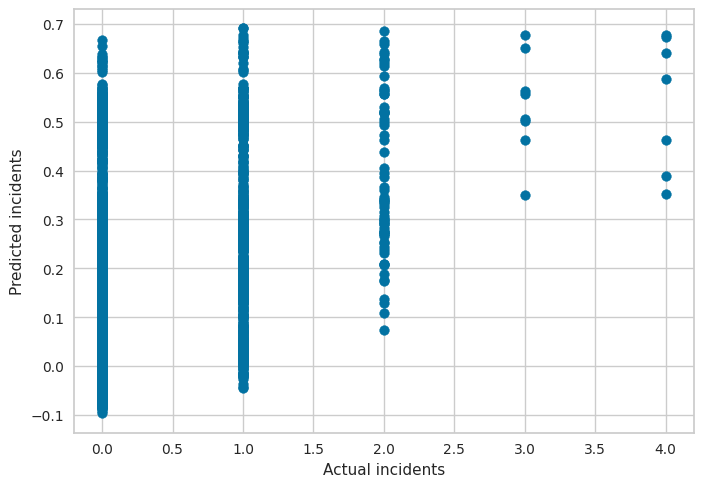

In [240]:
plt.scatter(y_test,pred_lin)
plt.xlabel('Actual incidents')
plt.ylabel('Predicted incidents')
plt.show()

The model doesn't predict very well as its values stay under 1 and the R2 score is quite low. Because the predictions from the days with different incident ammounts don't really differ then we can't really differentiate the more active days frome more calmer days.

Next I'll use pycaret to test different regression models and find the best one.

In [241]:
from pycaret.regression import *
df2 = pd.DataFrame(df2, columns=['area','population','area_km2','area_population_density','foot_traffic','area_type','socially_vulnerable_zone','minorities_zone','student_zone','nightlife_zone','day_of_week','hour','is_weekend','is_night','weather','incident_count'])
reg_setup=setup(data=df2, target='incident_count')

,Description,Value
0,Session id,845
1,Target,incident_count
2,Target type,Regression
3,Original data shape,"(38880, 16)"
4,Transformed data shape,"(38880, 57)"
5,Transformed train set shape,"(27216, 57)"
6,Transformed test set shape,"(11664, 57)"
7,Numeric features,9
8,Categorical features,6
9,Rows with missing values,100.0%


In [242]:
EXCLUDE_MODELS=[]
best_reg=compare_models(exclude=EXCLUDE_MODELS,errors='ignore')
best_reg

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.1492,0.1000,0.3159,0.1972,0.0000,0.7529,0.6310
catboost,CatBoost Regressor,0.1475,0.1031,0.3208,0.1701,0.0000,0.7403,2.1490
br,Bayesian Ridge,0.1657,0.1047,0.3233,0.1597,0.0000,0.7541,0.1880
ridge,Ridge Regression,0.1660,0.1047,0.3233,0.1596,0.0000,0.7526,0.1260
lar,Least Angle Regression,0.1661,0.1047,0.3233,0.1596,0.0000,0.7525,0.1290
lr,Linear Regression,0.1667,0.1048,0.3234,0.1592,0.0000,0.7525,0.5800
omp,Orthogonal Matching Pursuit,0.1557,0.1081,0.3284,0.1334,0.0000,0.7797,0.1180
xgboost,Extreme Gradient Boosting,0.1482,0.1091,0.3301,0.1206,0.0000,0.7474,0.2150
llar,Lasso Least Angle Regression,0.1810,0.1250,0.3530,-0.0006,0.0000,0.9087,0.1190
lasso,Lasso Regression,0.1810,0.1250,0.3530,-0.0006,0.0000,0.9087,0.1170


GradientBoostingRegressor(random_state=845)

In [243]:
evaluate_model(best_reg)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

We see that all the regression models predict quite badly as they all have a low R2 score. The most successful model is gbr. It manages to predict better and gives higher numbers but still has the same problems as the linear regression model.

Next we create the decision tree model and use it to predict the test data.

In [244]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [245]:
pred_tree=tree.predict(X_test)
pred_tree

array([0, 0, 0, ..., 0, 0, 0])

In [246]:
tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [247]:
tree_accuracy=tree.score(X_test,y_test)
print(tree_accuracy)
f1_score(y_test, pred_tree, average='macro')

0.8942901234567902


0.22520321418592554

We see that it is more accurate than the regression model.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

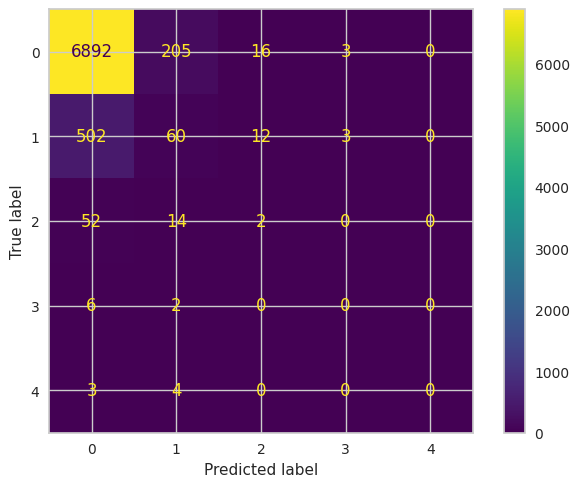

In [248]:
import matplotlib.pyplot as plt
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_test, pred_tree)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1, 2,3,4])

cm_display.plot()
plt.show()

We see that the model mostly predicted that there will be 0 incidents with the maximum of predicting there will be 3 incidents. The highes incident ammount it predicted correctly was 2 which it got right twice.